In [3]:
import numpy as np
import matplotlib.pyplot as plt
##!pip install muldoon 

from scipy.stats import mode

from muldoon.met_timeseries import PressureTimeseries
from muldoon.utils import *
from muldoon.read_data import *

In [4]:
import math 

## File name must be changed to the correct file path per sol
day = 685

def dayify(input_sol):
    "Converts an inputted min or max to the 4 digit format used by PDS"
    output_sol = input_sol
    if input_sol < 10:
        return "000" + str(input_sol)
    elif input_sol < 100: 
        return "00" + str(input_sol)
    elif input_sol < 1000:
        return "0" + str(input_sol)
    else:
        return str(input_sol)

#sols go from 0 to 89, then from then until 1739 they have 119 sols in each file
file_min = 0
file_max = 0
if day < 90:
    file_min = 0
    file_max = 89
elif day < 180:
    file_min = 90
    file_max = 179
else:
    file_min = 60 + math.floor(day/120) * 120
    file_max = 179 + math.floor(day/120) * 120
str_file_min = dayify(file_min)
str_file_max = dayify(file_max)
str_day = dayify(day)


#file_loc 

filename = (
    "https://pds-atmospheres.nmsu.edu/PDS/data/PDS4/Mars2020/"
    "mars2020_meda/data_derived_env/"
    f"sol_{str_file_min}_{str_file_max}/sol_{str_day}/"
    f"WE__{str_day}___________DER_PS__________________P01.CSV"
)

time, pressure = read_Perseverance_PS_data(filename)

time = np.array(time)
pressure = np.array(pressure)

mask = pressure < 1_000_000

time = time[mask]
pressure = pressure[mask]

times, pressures = break_at_gaps(time, pressure)

for t, p in zip(times, pressures):
    mask = p < 1_000_000
    filtered_times.append(t[mask])
    filtered_pressures.append(p[mask])

    

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

for i in range(len(times)):
#     plt.axvline(time[0:-1][gaps][i])
    ax.scatter(times[i], pressures[i], marker='.')
ax.grid(True)

Processing file: https://pds-atmospheres.nmsu.edu/PDS/data/PDS4/Mars2020/mars2020_meda/data_derived_env/sol_0660_0779/sol_0685/WE__0685___________DER_PS__________________P01.CSV


NameError: name 'filtered_times' is not defined

Text(0, 0.5, 'Pressure (Pa)')

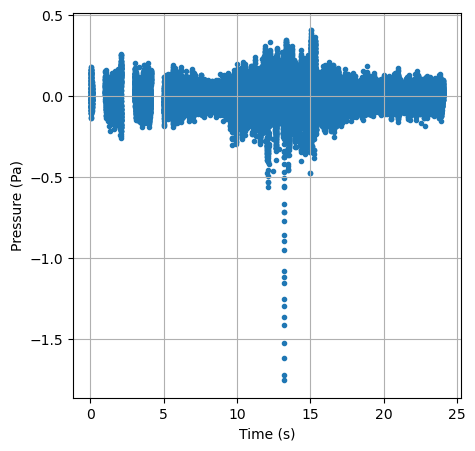

In [15]:
mt = PressureTimeseries(time, pressure)

window_size = 500./3600 # window size is 500 seconds
mt.detrend_timeseries_boxcar(window_size)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.scatter(mt.time, mt.detrended_data, marker='.')
ax.grid(True)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

10


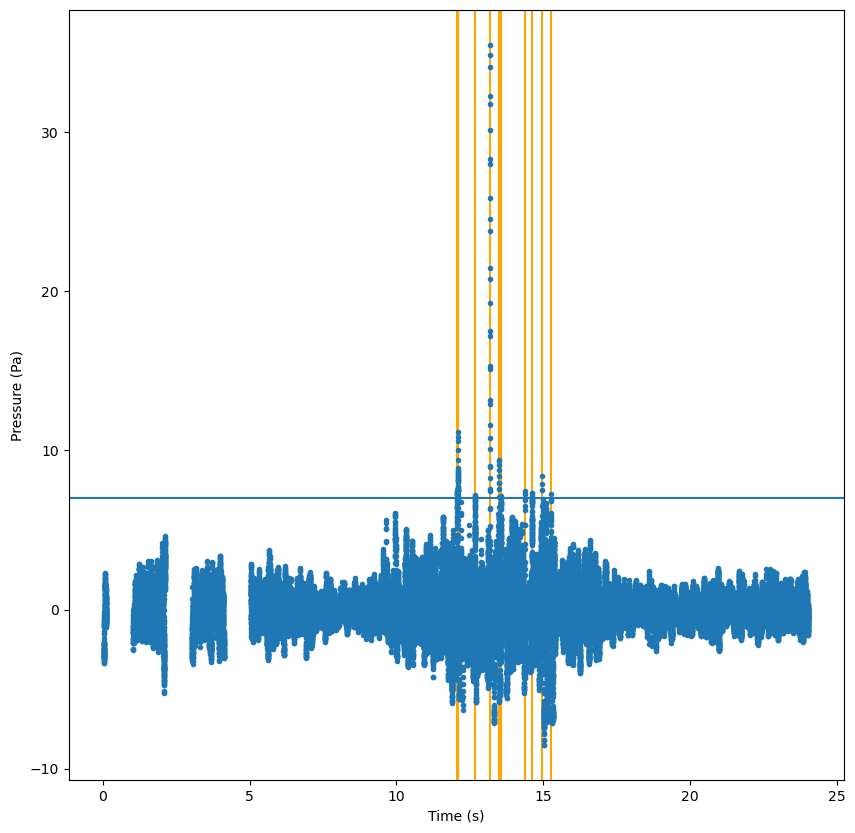

In [19]:
matched_filter_width = 2.*mt.sampling
matched_filter_depth = 1./np.pi
distance_between_peaks = 35
detection_threshold = 7


conv = mt.apply_lorentzian_matched_filter(matched_filter_width, matched_filter_depth)
vortices = mt.find_vortices(detection_threshold=detection_threshold, distance=distance_between_peaks)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.plot(mt.time, mt.convolution, ls='', marker='.')
ax.axhline(detection_threshold)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

for i in range(len(mt.peak_indices)):
    ax.axvline(mt.time[mt.peak_indices[i]], color="orange", zorder=-1)

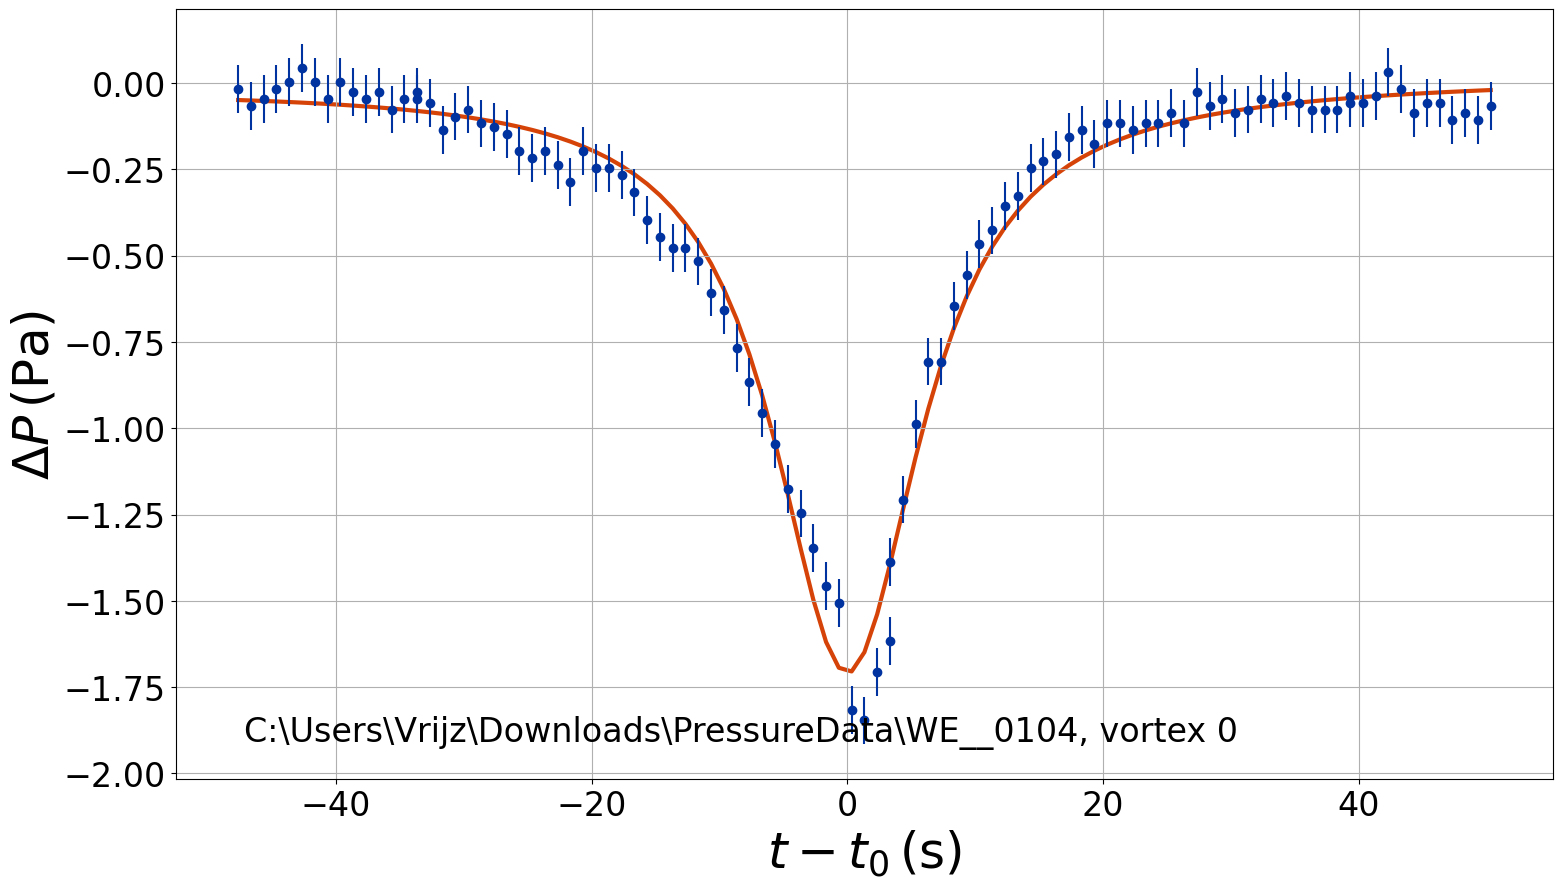

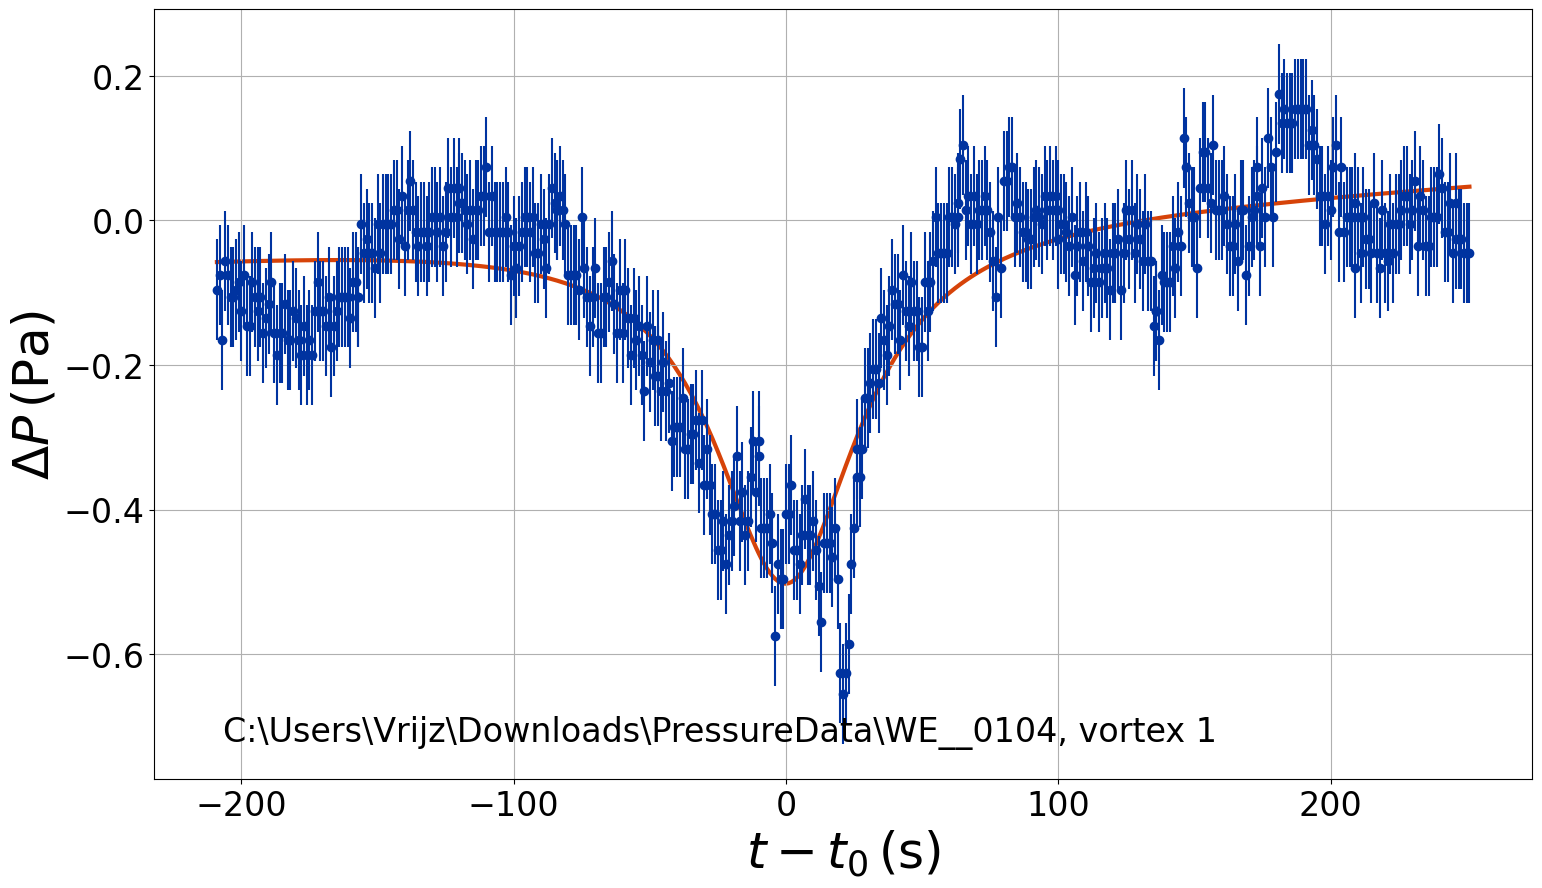

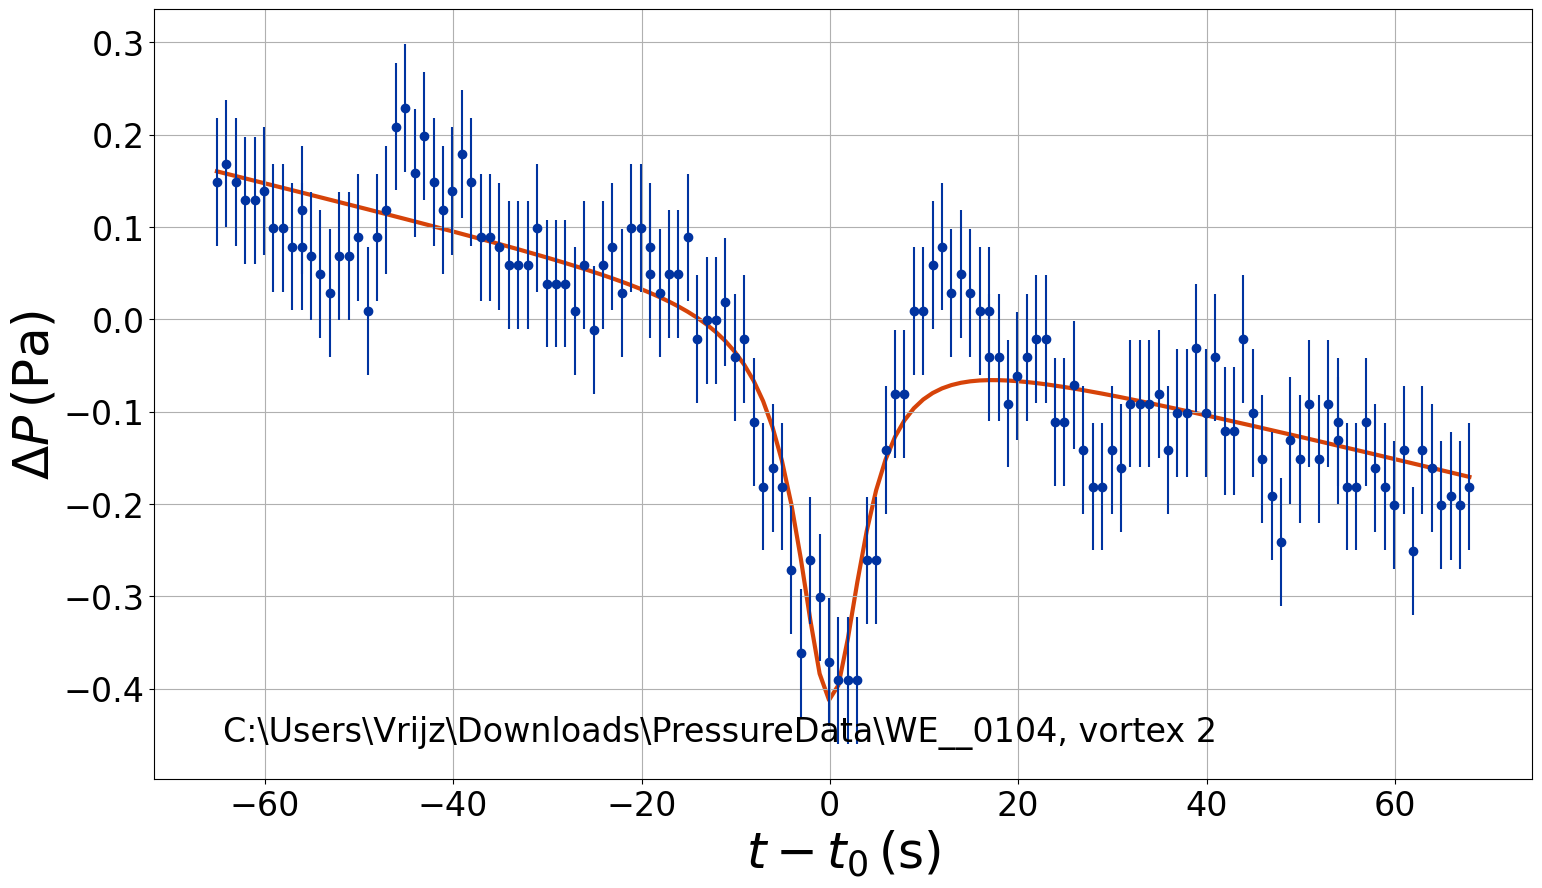

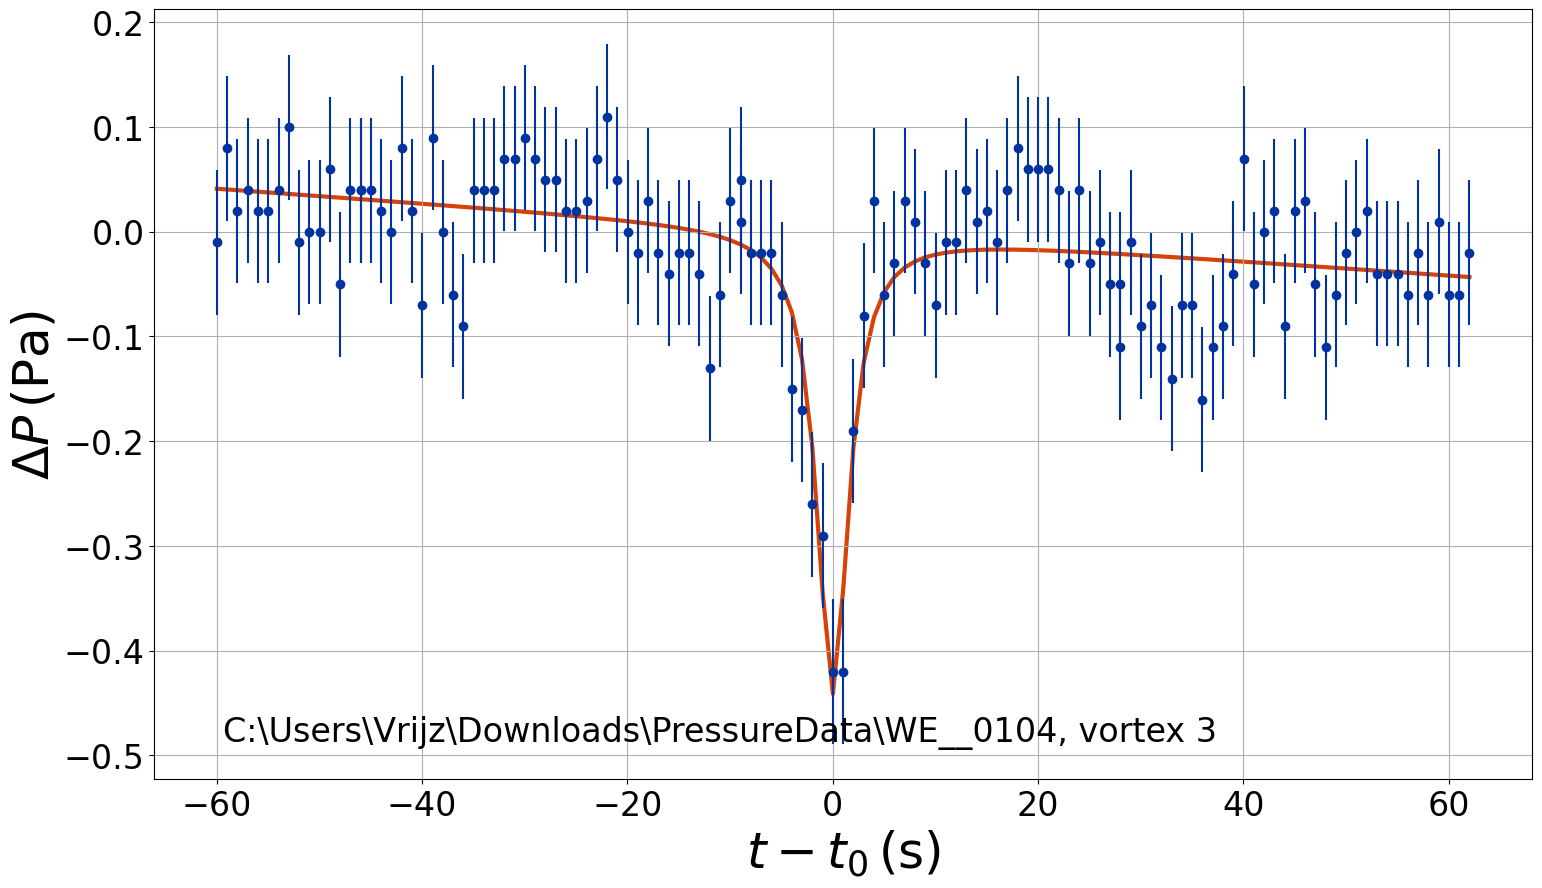

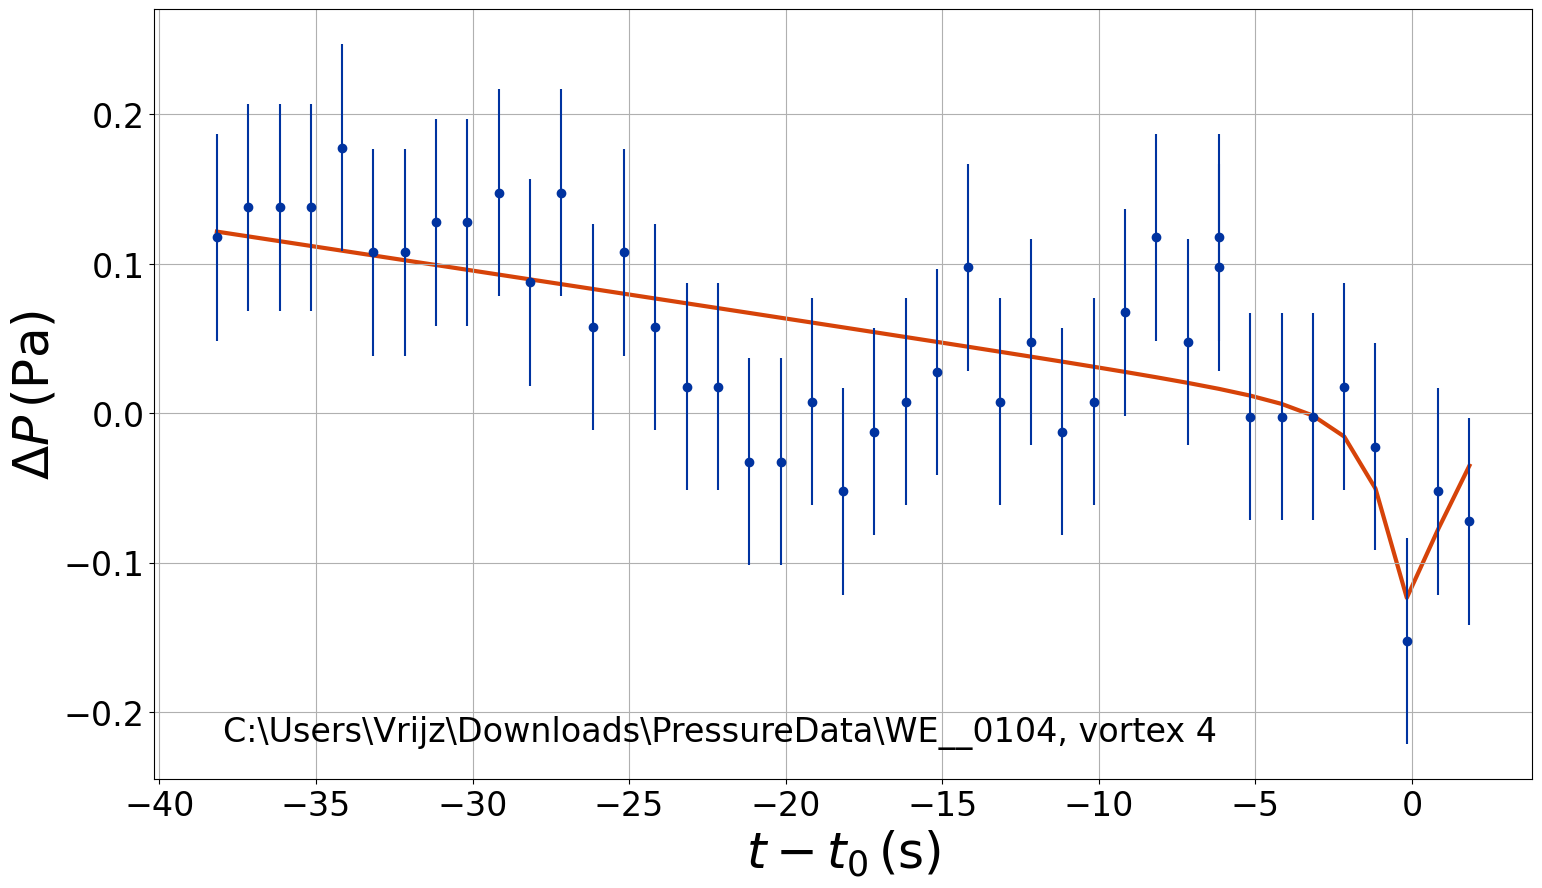

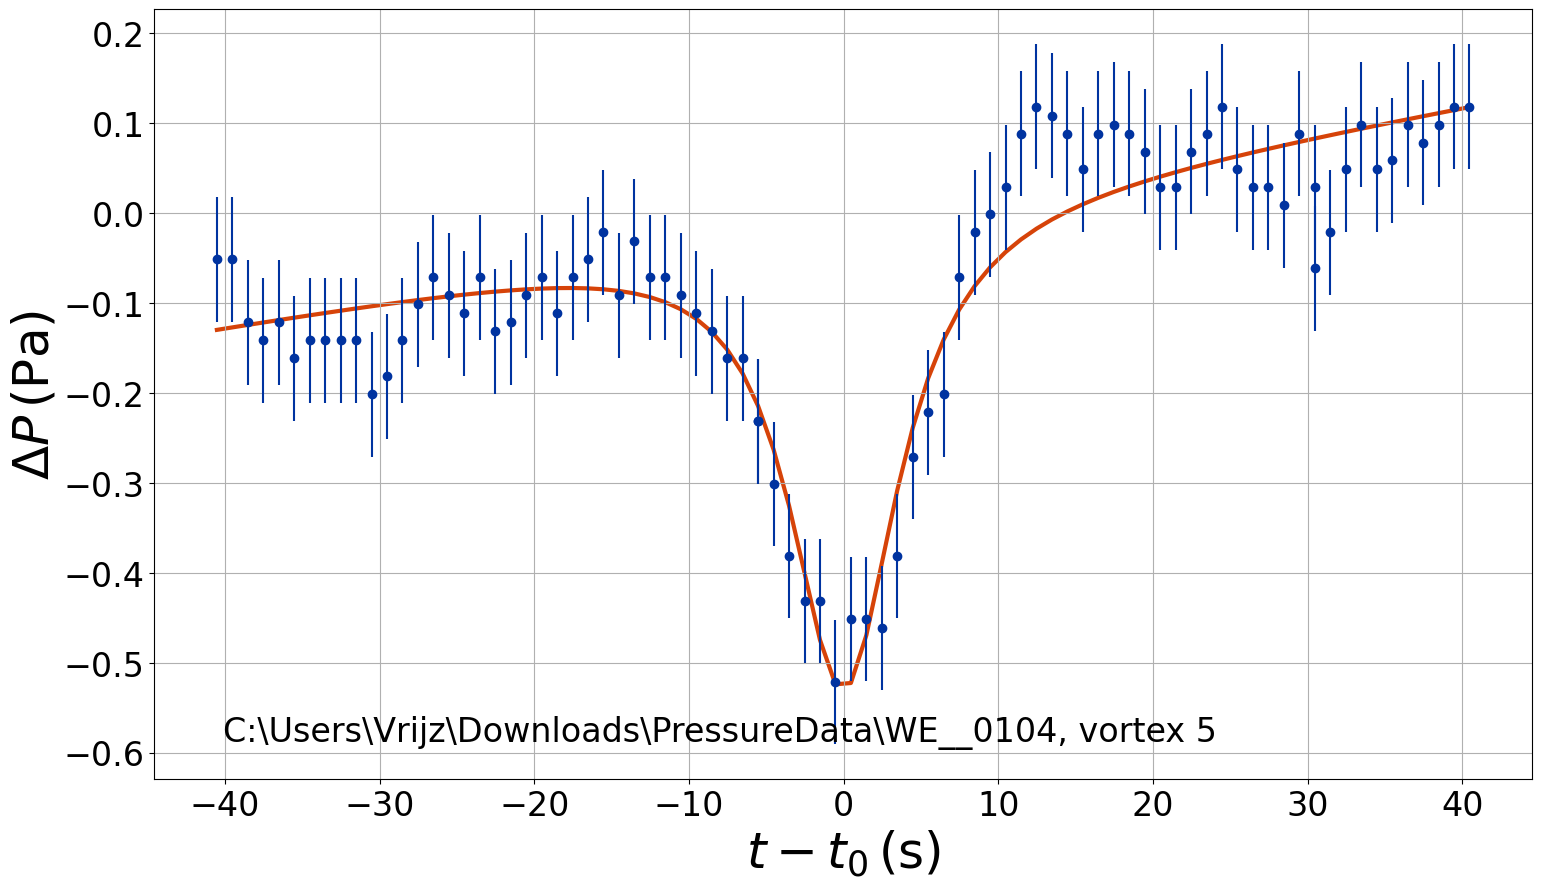

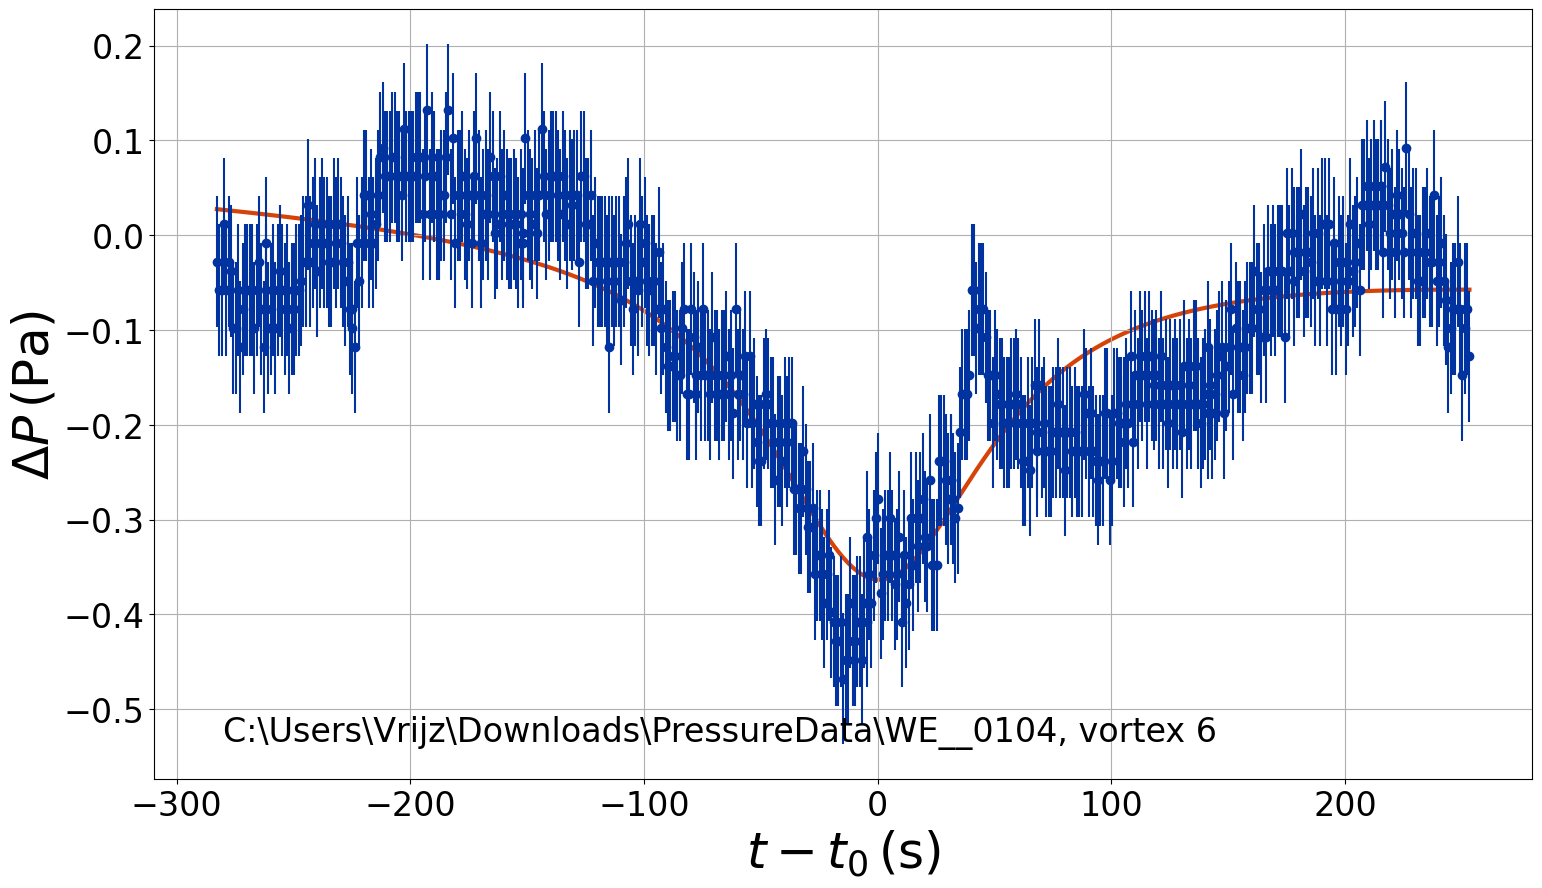

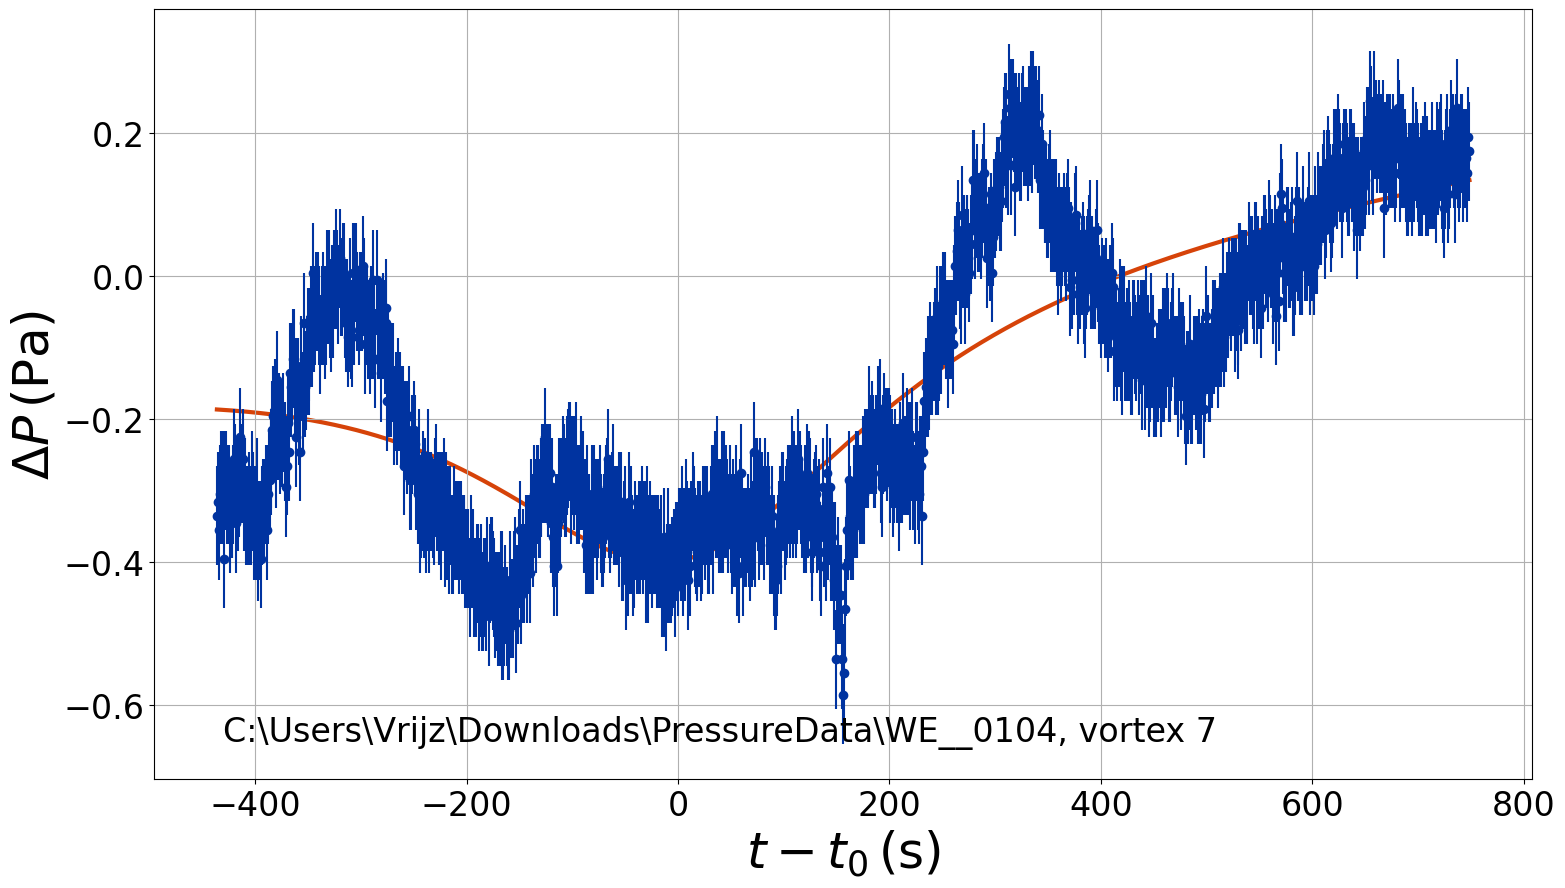

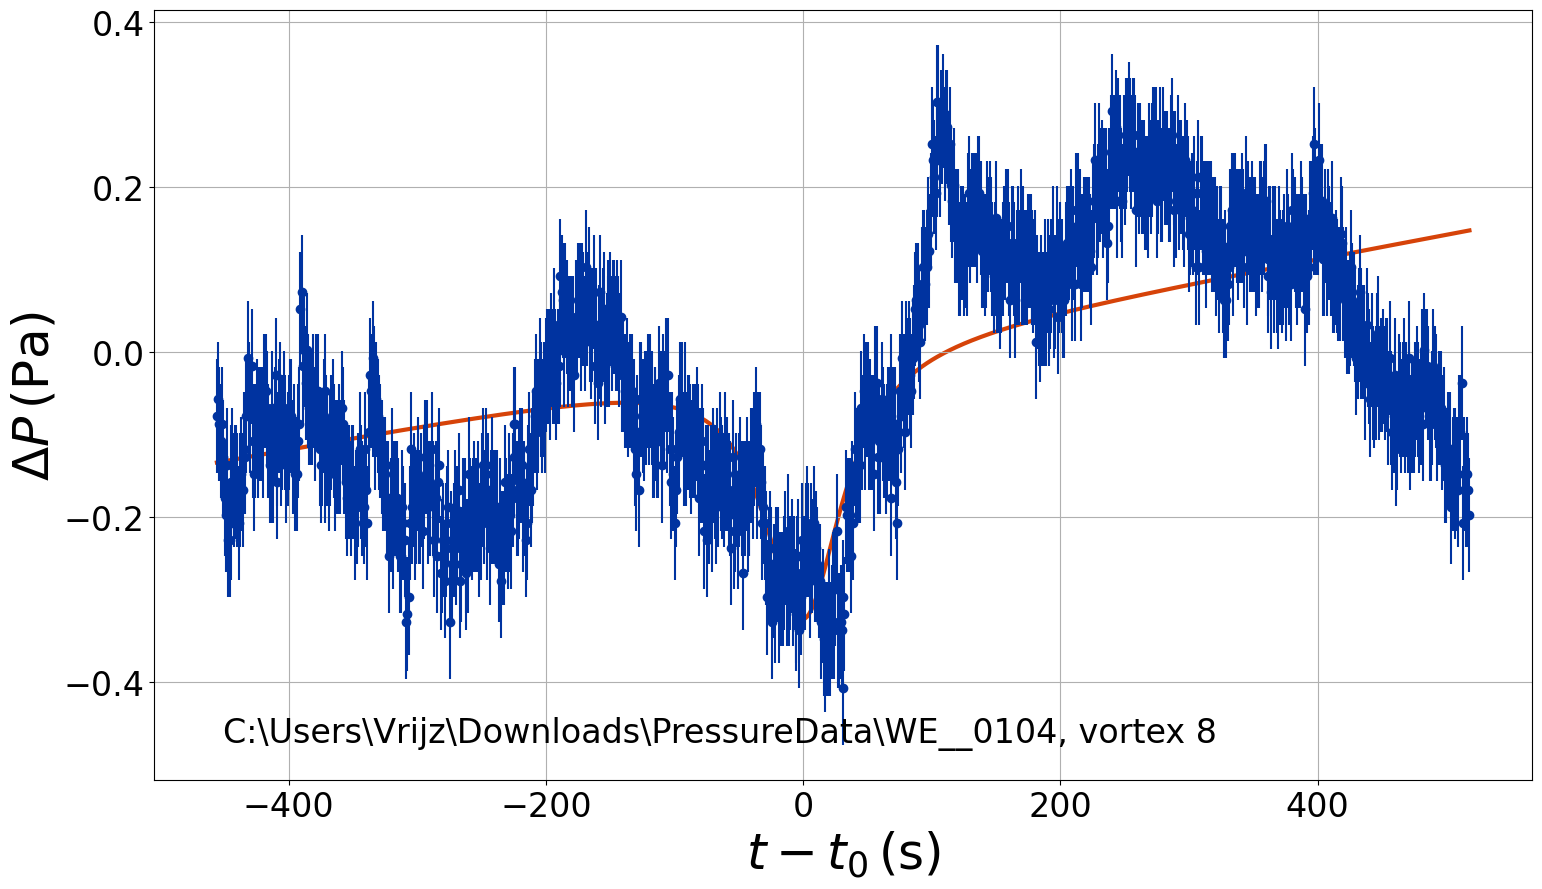

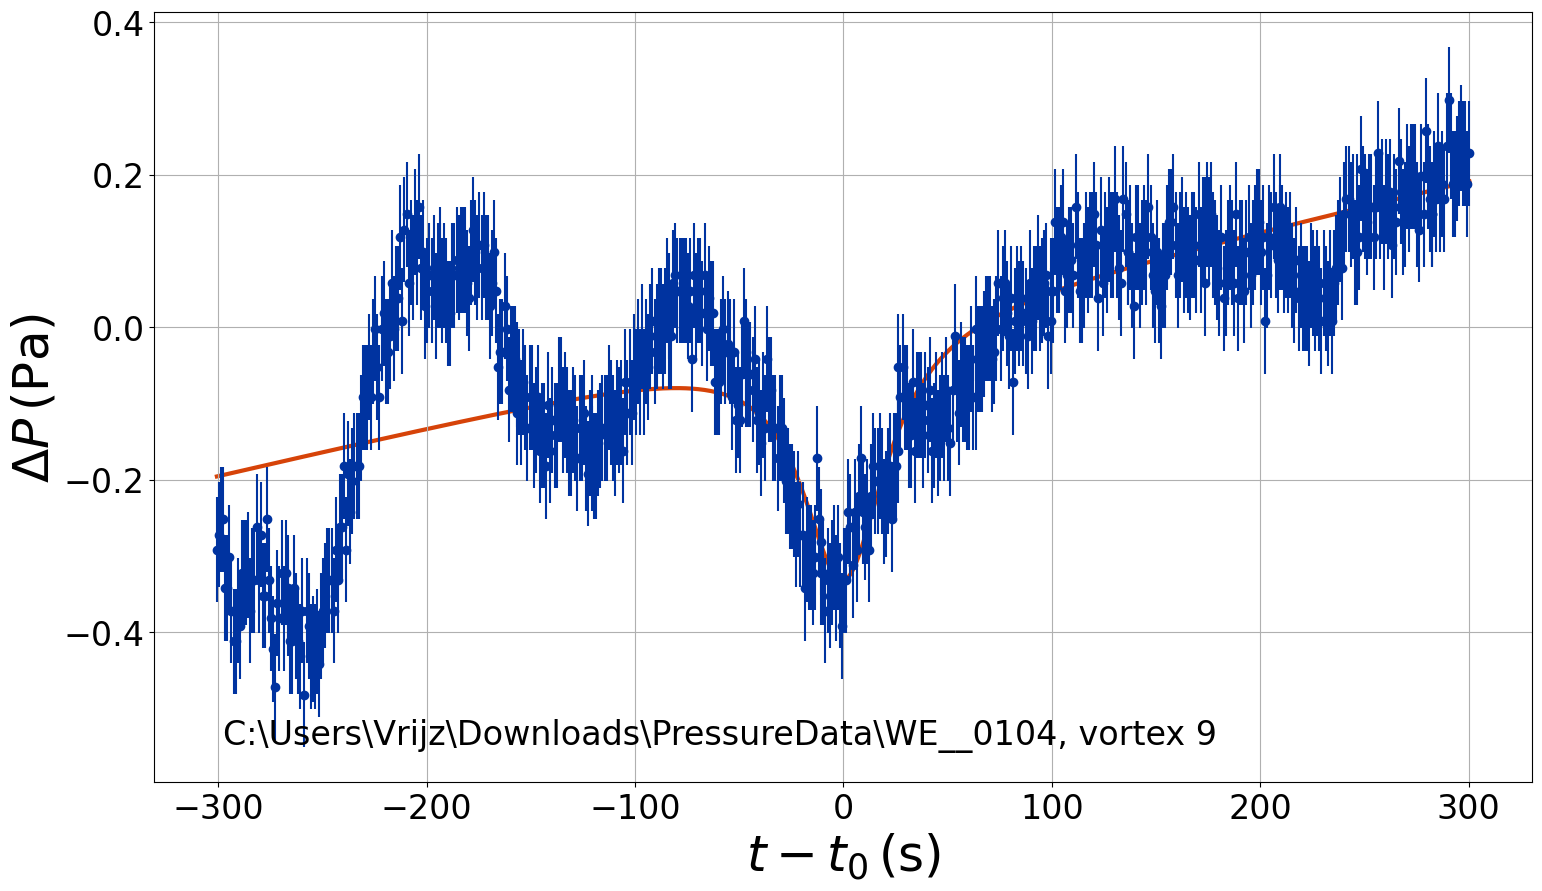

In [17]:
import shutil
import os

#Reduce spam of .csv files from muldoon API but keep it running and making the graphs
#It still needs a file path to load the graphs
dataFolder = r"C:\Users\Vrijz\Downloads\PressureData"

#To save the graphs locally for easy word use
graphsFolder = r"C:\Users\Vrijz\Downloads\PressureGraphs"

## Change sol number here too
mt.fit_all_vortices(filepath=os.path.join(dataFolder, "WE__0104"))


for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(
        os.path.join(graphsFolder, f"vortex_fit_{i-1}.png"),
        dpi=300,
        bbox_inches='tight'
    )

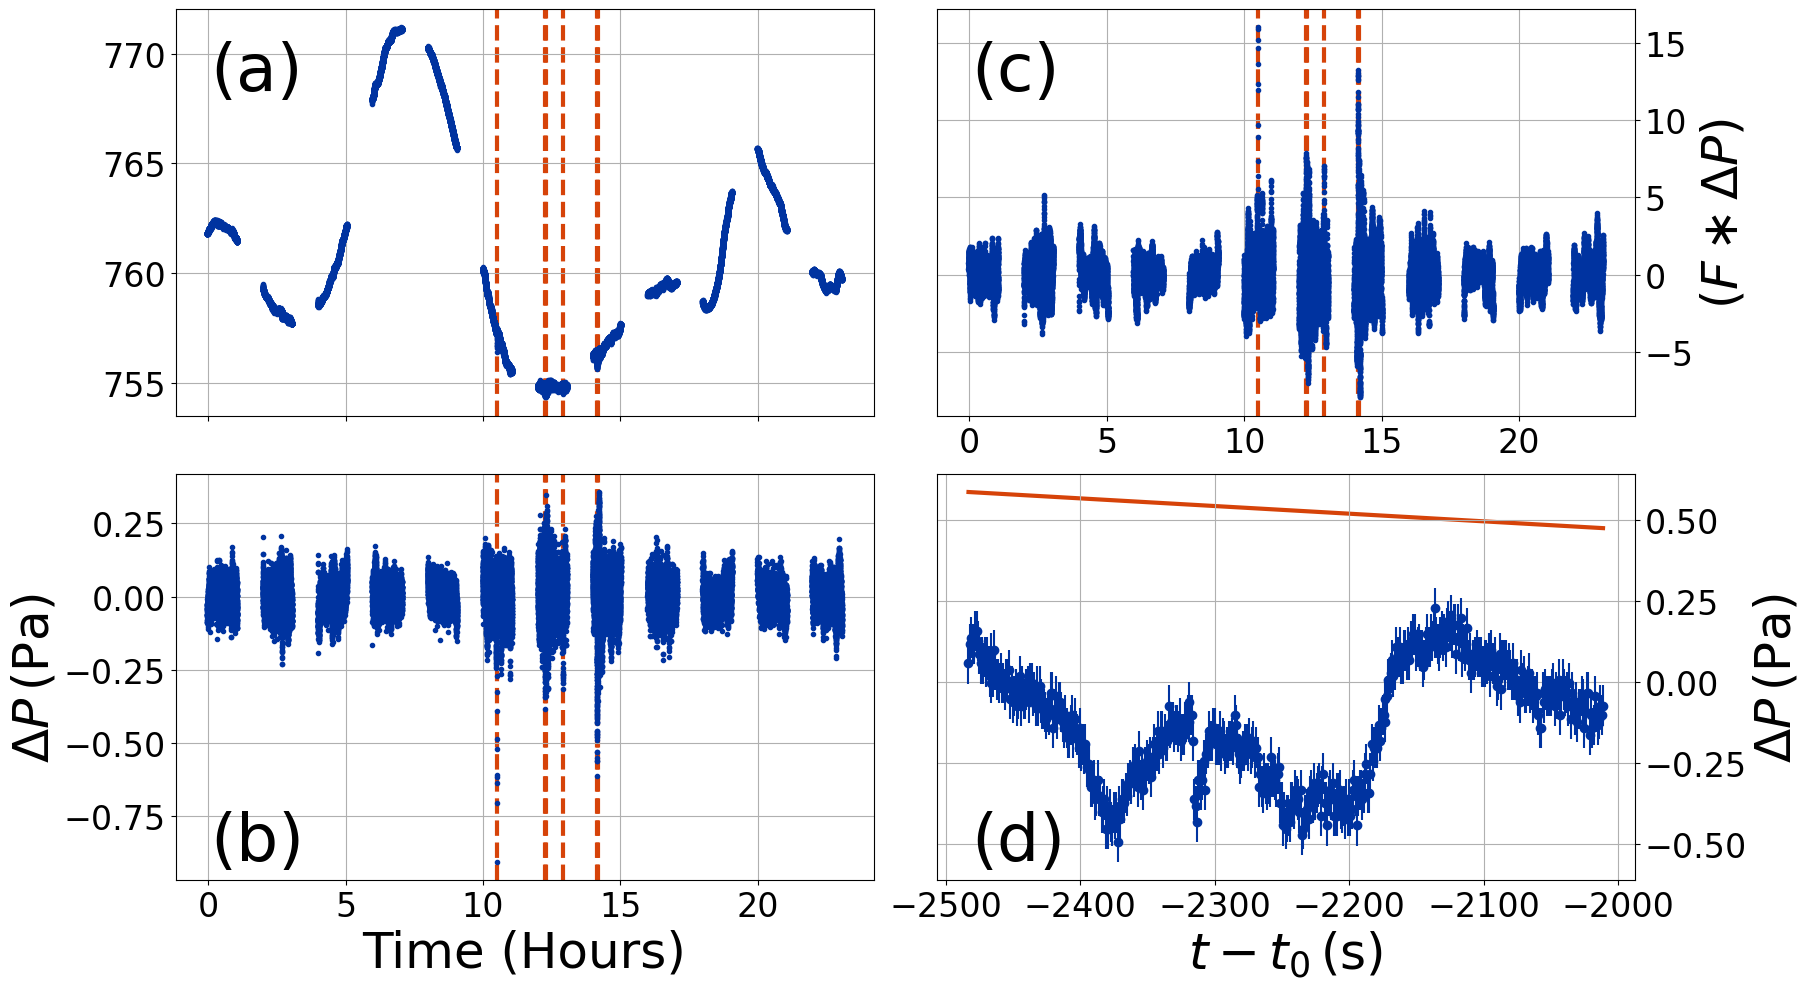

In [81]:
import os
import shutil

# Make final conditioned data figure
finalFourGraphsFolder = r"C:\Users\Vrijz\Downloads\FinalFourGraphs"

#Clear and recreate 
shutil.rmtree(finalFourGraphsFolder)
os.makedirs(finalFourGraphsFolder, exist_ok=True)

 
mt.make_conditioned_data_figure(which_vortex=4);
plt.tight_layout()

for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(
        os.path.join(finalFourGraphsFolder, f"vortex_fit_{i}.png"),
        dpi=300,
        bbox_inches='tight'
    )